# Task 2: Implementing Word Embedding

For this assignment, I'll be using FastText.

## Why?
- FastText handles out of vocabulary (OOV) words more effectively in comparison
- While Word2Vec and GloVe fail on unseen words, FastText breaks words down into subword n-grams, allowing it to compute embeddings even for misspelled words

In [20]:
from gensim.models import KeyedVectors
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [3]:
model_path = 'cc.en.300.vec'  # or 'cc.en.300.vec.gz' if compressed
print("Loading FastText vectors")
model = KeyedVectors.load_word2vec_format(model_path, binary=False)
print("Model loaded successfully")

Loading FastText vectors
Model loaded successfully


In [4]:
def get_embedding(word):
    try:
        return model[word]
    except KeyError:
        #Returns 0 vector 
        print(f"'{word}' not found. Returning zero vector.")
        return [0.0] * model.vector_size

In [5]:
word1 = input("Enter the first word: ").strip()
word2 = input("Enter the second word: ").strip()

embedding1 = get_embedding(word1)
embedding2 = get_embedding(word2)

print(f"Embedding for '{word1}':\n", embedding1)
print(f"Embedding for '{word2}':\n", embedding2)

Embedding for 'pale':
 [-0.1069  0.0123 -0.1717  0.1601  0.0069 -0.1641  0.2415  0.0537  0.0911
 -0.0072 -0.0081 -0.1243 -0.0462 -0.1684 -0.0125  0.1506 -0.0787 -0.0432
 -0.0135 -0.1135  0.0917 -0.016   0.0189  0.0948  0.0846  0.0514 -0.0212
 -0.079   0.1454  0.1418  0.0733  0.1005  0.0359  0.193   0.0086 -0.0338
  0.0937 -0.0164  0.0759  0.109   0.0378 -0.0635  0.0735 -0.0086 -0.085
  0.1244  0.0817 -0.2721  0.0212 -0.0416 -0.0305 -0.0431  0.1461 -0.0443
  0.06    0.1014  0.0409  0.0376 -0.0965 -0.0539  0.0175  0.1139  0.1651
 -0.0785 -0.043   0.0409 -0.0039 -0.1656 -0.15   -0.1303  0.0399  0.0097
 -0.0262 -0.0795  0.0609  0.053   0.176   0.1047  0.0817 -0.1319 -0.0336
 -0.0706  0.0247 -0.0682 -0.0818 -0.0454  0.1073  0.0551 -0.1319  0.0839
 -0.0821  0.1305 -0.0556  0.0445 -0.0867 -0.0889 -0.0405 -0.0171  0.0826
 -0.013  -0.1441 -0.0241  0.047   0.0605  0.106   0.0484 -0.0768 -0.0774
  0.1944  0.0431 -0.0643  0.097   0.1104  0.0491  0.0248 -0.069  -0.0486
 -0.0351 -0.0989 -0.0478 -0.0

# Cosine Similarity and Visualization

Cosine similarity measures the angle between word vectors, capturing semantic similarity while ignoring differences in magnitude. It helps identify words with similar meanings by comparing their directional alignment in the embedding space.


Cosine similarity between 'pale' and 'pail': 0.1839

Batch Cosine Similarities:
jolly - molly: 0.1752
friends - tree: 0.1300
lion - eat: 0.2061
whale - wail: 0.2221


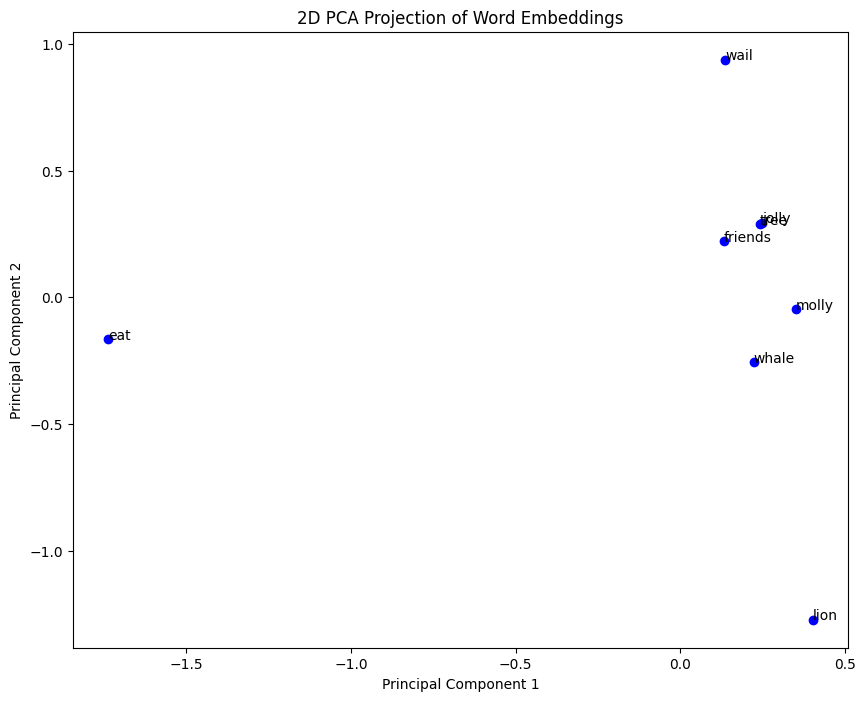

In [19]:
#Words pair inputs: jolly,molly;friends,tree;lion,eat;whale,wail
def cosine_similarity(vec1, vec2):
    """
    Computes cosine similarity between two vectors.
    """
    dot_product = np.dot(vec1, vec2)
    norm_product = np.linalg.norm(vec1) * np.linalg.norm(vec2)
    if norm_product == 0:
        return 0.0
    return dot_product / norm_product

single_similarity = cosine_similarity(embedding1, embedding2)
print(f"\nCosine similarity between '{word1}' and '{word2}': {single_similarity:.4f}")

def batch_cosine_similarity(pairs, model):
    """
    Computes cosine similarity for a list of word pairs.
    Returns a list of (word1, word2, similarity) tuples.
    """
    results = []
    for w1, w2 in pairs:
        if w1 in model and w2 in model:
            sim = cosine_similarity(model[w1], model[w2])
            results.append((w1, w2, sim))
        else:
            results.append((w1, w2, None))
    return results

user_input = input("Enter word pairs (format: word1,word2;word3,word4;...): ")
word_pairs = [tuple(pair.strip().split(',')) for pair in user_input.strip().split(';')]

batch_results = batch_cosine_similarity(word_pairs, model)

print("\nBatch Cosine Similarities:")
for w1, w2, sim in batch_results:
    if sim is not None:
        print(f"{w1} - {w2}: {sim:.4f}")
    else:
        print(f"{w1} - {w2}: One or both words not found in vocabulary.")

def plot_embeddings_pca(words, model):
    """
    Creates a 2D PCA scatter plot for a list of words.
    """
    vectors = []
    labels = []
    
    for word in words:
        if word in model:
            vectors.append(model[word])
            labels.append(word)
        else:
            print(f"Warning: '{word}' not in vocabulary. Skipping.")
    
    if len(vectors) < 2:
        print("Not enough words for visualization.")
        return
    
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(vectors)
    
    # Plot
    plt.figure(figsize=(10, 8))
    plt.scatter(reduced[:, 0], reduced[:, 1], color='blue')
    for i, label in enumerate(labels):
        plt.annotate(label, (reduced[i, 0], reduced[i, 1]))
    
    plt.title("2D PCA Projection of Word Embeddings")
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.show()

plot_words = []

for pair in word_pairs:
    for word in pair:
        plot_words.append(word)

plot_embeddings_pca(plot_words, model)

# Novel Dissimilarity Metric

For this part of the exercise, I'll be using Euclidean distance.
- Euclidean distance incldes magnitude information which helps detect differences in scale between words even if they point in similar directions
- Cosine similarity only considers the angles between the word but doesn't account for anything else.

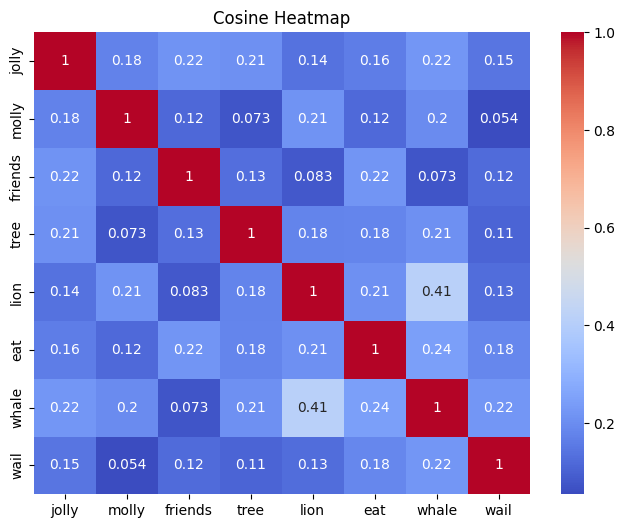

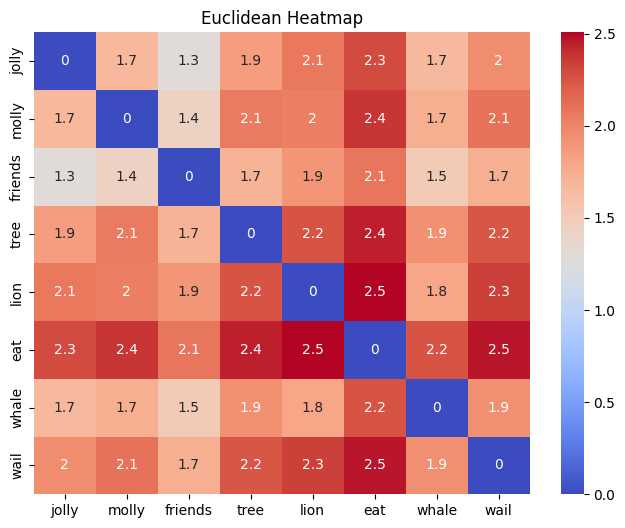

In [21]:
def euclidean_distance(vec1, vec2):
    return np.linalg.norm(vec1 - vec2)

def compute_similarity(w1, w2, model, metric='euclidean'):
    if w1 not in model or w2 not in model:
        return None

    vec1 = model[w1]
    vec2 = model[w2]
    
    if metric == 'cosine':
        return cosine_similarity(vec1, vec2)
    elif metric == 'euclidean':
        return euclidean_distance(vec1, vec2)
    else:
        raise ValueError(f"Unsupported metric: {metric}") 

def plot_similarity_heatmap(words, model, metric='cosine'):
    n = len(words)
    matrix = np.zeros((n, n))
    
    for i in range(n):
        for j in range(n):
            if words[i] in model and words[j] in model:
                if metric == 'cosine':
                    score = cosine_similarity(model[words[i]], model[words[j]])
                elif metric == 'euclidean':
                    score = euclidean_distance(model[words[i]], model[words[j]])
                else:
                    raise ValueError(f"Unsupported metric: {metric}")
                matrix[i, j] = score
            else:
                matrix[i, j] = np.nan

    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, xticklabels=words, yticklabels=words, cmap='coolwarm')
    plt.title(f"{metric.capitalize()} Heatmap")
    plt.show()

user_input = input("Enter word pairs (format: word1,word2;word3,word4;...): ")
word_pairs = [tuple(pair.strip().split(',')) for pair in user_input.strip().split(';')]

words = []
for pair in word_pairs:
    for word in pair:
        words.append(word)

plot_similarity_heatmap(words, model, metric='cosine')
plot_similarity_heatmap(words, model, metric='euclidean')

